# 1. Business Problem Understanding

**Problem Statement**

- Retail companies generate thousands of sales records every day. Simply visualizing past sales is useful, but it does not help businesses make future decisions.

- The objective is to build an AI-based Sales Forecasting Dashboard that predicts future sales using historical sales data.

- The dashboard helps management answer questions like:

    - How much sales can be expected next month?
    - Which region will generate maximum revenue?
    - Which category is growing?
    - How much inventory is required?
    - Expected profit?

**Business Objectives**

- Predict Future Sales

- Improve Inventory Planning

- Reduce Stock Out

- Improve Revenue

- Help Business Decision Making

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor


from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)



# 2.Data Understanding

- For the AI-Based Sales Forecasting Dashboard, the dataset contains historical retail sales transactions, including customer information, product details, order dates, regions, categories, sales, profit, quantity, and discounts. These features are used to analyze past business performance and build a machine learning model capable of forecasting future sales.

**The key objectives of this phase are:**

  - Understand the dataset dimensions (rows and columns).
  - Identify numerical and categorical features.
  - Examine data types of each column.
  - Detect missing and duplicate values.
  - Generate statistical summaries of numerical variables.
  - Explore unique values in categorical features.
  - Prepare the dataset for preprocessing and model training.

In [2]:
# ======================================
# Dataset Columns Description
# ======================================

import streamlit as st


st.subheader("📋 Dataset Column Description")

column_info = pd.DataFrame({
    "Column Name": [
        "Row ID",
        "Order ID",
        "Order Date",
        "Ship Date",
        "Ship Mode",
        "Customer ID",
        "Customer Name",
        "Segment",
        "Country",
        "City",
        "State",
        "Postal Code",
        "Region",
        "Product ID",
        "Category",
        "Sub-Category",
        "Product Name",
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ],

    "Simple Explanation": [
        "A unique number assigned to each record.",
        "A unique ID for every customer order.",
        "The date on which the customer placed the order.",
        "The date on which the order was shipped.",
        "The shipping method used to deliver the order.",
        "A unique identification number for each customer.",
        "The name of the customer who placed the order.",
        "The type of customer (Consumer, Corporate, Home Office).",
        "The country where the customer is located.",
        "The city where the customer is located.",
        "The state where the customer is located.",
        "The postal/ZIP code of the customer's location.",
        "The sales region (East, West, Central, South).",
        "A unique identification number for each product.",
        "The main category of the product.",
        "A smaller classification within the product category.",
        "The name of the product sold.",
        "The total sales amount earned from the order (Target Variable).",
        "The number of units purchased.",
        "The discount applied to the product.",
        "The profit earned after deducting costs."
    ]
})

st.table(column_info)
column_info

2026-07-05 19:57:29.812 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 19:57:30.402 
  command:

    streamlit run C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-05 19:57:30.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 19:57:30.404 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 19:57:30.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 19:57:30.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 19:57:30.413 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 19:57:30.414 Threa

,Column Name,Simple Explanation
0,Row ID,A unique number assigned to each record.
1,Order ID,A unique ID for every customer order.
2,Order Date,The date on which the customer placed the order.
3,Ship Date,The date on which the order was shipped.
4,Ship Mode,The shipping method used to deliver the order.
5,Customer ID,A unique identification number for each customer.
6,Customer Name,The name of the customer who placed the order.
7,Segment,"The type of customer (Consumer, Corporate, Hom..."
8,Country,The country where the customer is located.
9,City,The city where the customer is located.


In [3]:
df=pd.read_csv(r"C:\Users\Dell\OneDrive\Pictures\Documents\Major project\Salse store.csv",encoding='latin-1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [5]:
df.shape

(9994, 21)

In [6]:
df.size

209874

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# 3.Data Preprocessing
**Description**

- Data Preprocessing is the process of cleaning, transforming, and preparing the dataset before applying machine learning algorithms. Real-world datasets often contain missing values, duplicate records, incorrect data types, and categorical variables that must be handled before model training.

- For the AI-Based Sales Forecasting Dashboard, preprocessing ensures that the sales data is accurate, consistent, and ready for prediction. The main preprocessing tasks include handling missing values, removing duplicates, converting date columns, extracting useful date features, encoding categorical variables, and selecting the relevant features for model training.

**Objectives**
- Remove missing values.
- Remove duplicate records.
- Convert the Order Date into datetime format.
- Extract Year, Month, and Day from the order date.
- Convert categorical columns into numerical values.


   - Step 1: Check Missing Values

In [9]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

- Step 2: Check Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

- Step 3: Convert Order Date

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

- Step 4: Extract Date Features

In [12]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day

- Step 5: Encode Categorical Features

In [13]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_category = LabelEncoder()
le_segment = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Category"] = le_category.fit_transform(df["Category"])
df["Segment"] = le_segment.fit_transform(df["Segment"])

- Step 6: Check Value Count

In [14]:
df["Region"].value_counts()

Region
3    3203
1    2848
0    2323
2    1620
Name: count, dtype: int64

In [15]:
df["Segment"].value_counts()

Segment
0    5191
1    3020
2    1783
Name: count, dtype: int64

In [16]:
df["Category"].value_counts()

Category
1    6026
0    2121
2    1847
Name: count, dtype: int64

# 4.Exploratory Data Analysis (EDA)

**Description**

- Exploratory Data Analysis (EDA) is the process of analyzing and visualizing the cleaned dataset to discover patterns, trends, and relationships between variables. It helps understand business performance and identify insights before training the machine learning model.

- For the AI-Based Sales Forecasting Dashboard, EDA provides valuable insights into sales performance across different regions, product categories, and time periods. It also helps identify the top-selling products, profit trends, and seasonal sales patterns, which are useful for building an accurate forecasting model.

**Objectives**
  - Analyze sales performance across different regions.
  - Identify the best-performing product categories.
  - Understand monthly and yearly sales trends.
  - Find the top-selling products.
  - Analyze profit distribution.
  - Identify relationships between numerical variables.
  - Detect outliers in sales and profit.

**Sales by Region**
   - This chart compares total sales across different regions and helps identify the highest-performing sales region.

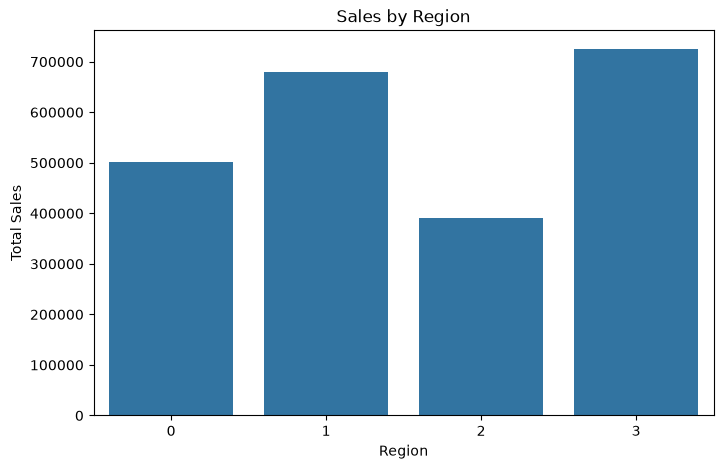

In [17]:
plt.figure(figsize=(8,5))

region_sales = df.groupby("Region")["Sales"].sum()

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

**Sales by Category**
  - This chart compares sales across different product categories.

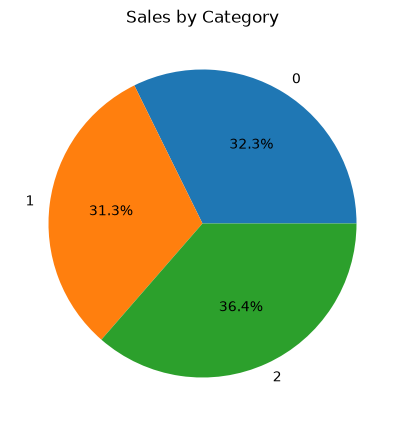

In [18]:
plt.figure(figsize=(7,5))

category_sales = df.groupby("Category")["Sales"].sum()

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales by Category")
plt.show()

**Monthly Sales Trend**
  - This line chart shows how sales change every month.

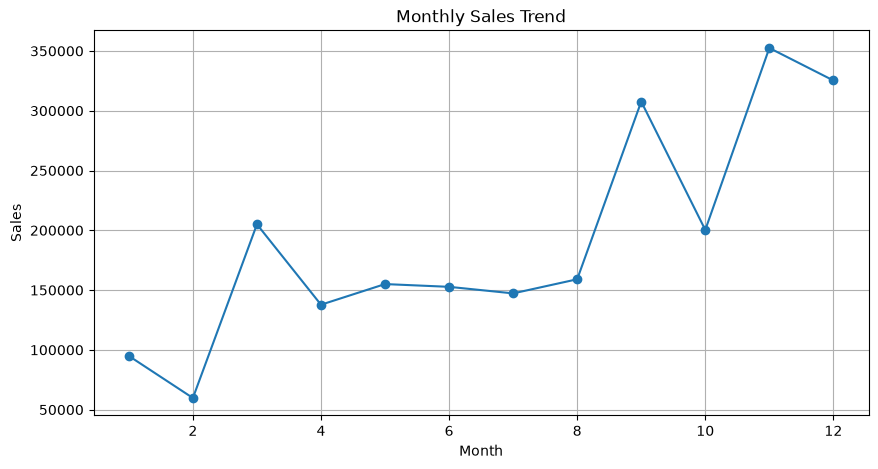

In [19]:
df["Month"] = df["Order Date"].dt.month

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

**Yearly Sales Trend**
  - This chart shows the total sales for each year.

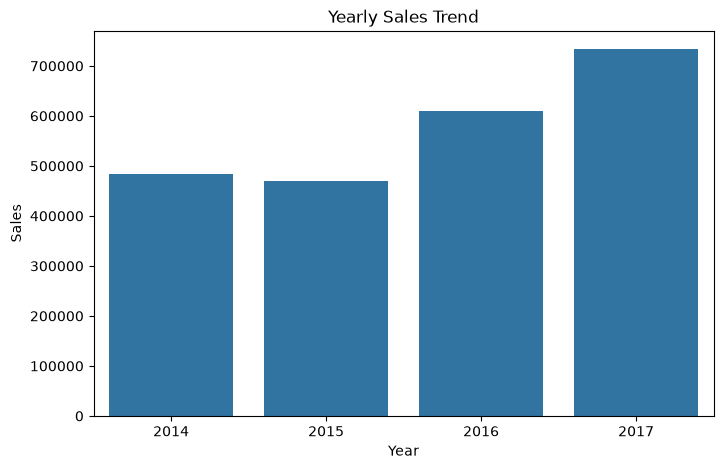

In [20]:
df["Year"] = df["Order Date"].dt.year

yearly_sales = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

**Top 10 Products**
  - This chart displays the ten products with the highest sales.

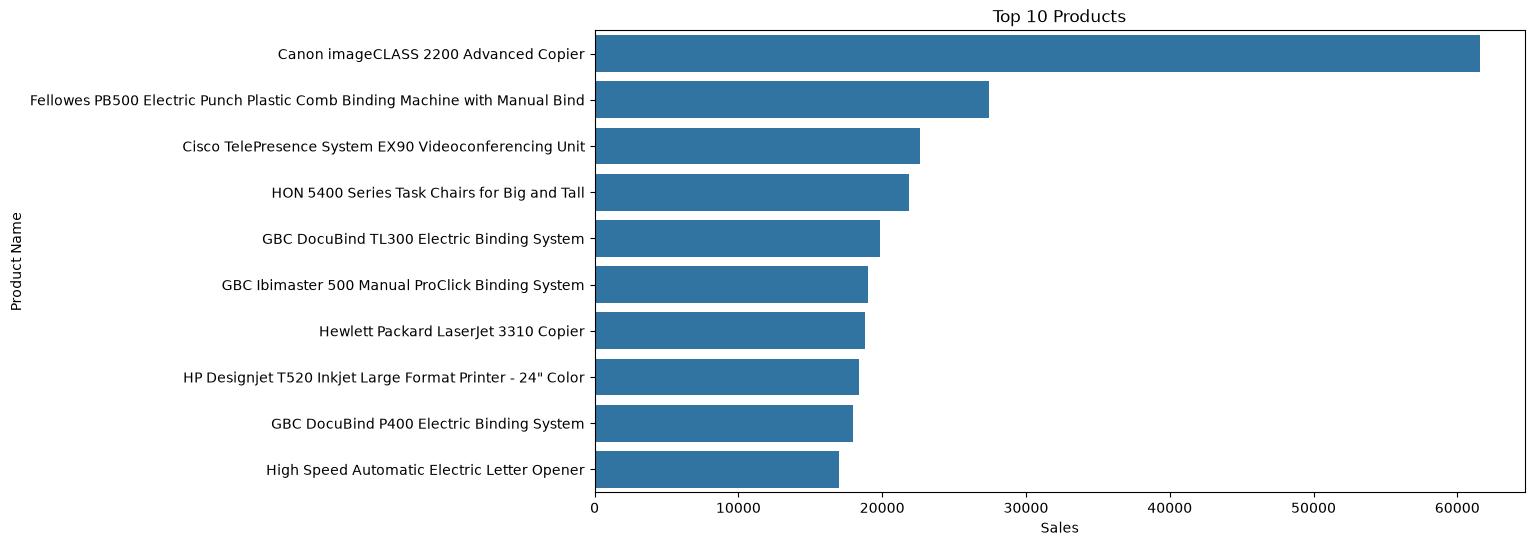

In [21]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.show()

**Profit by Region**
  - This chart compares the profit earned in each region.

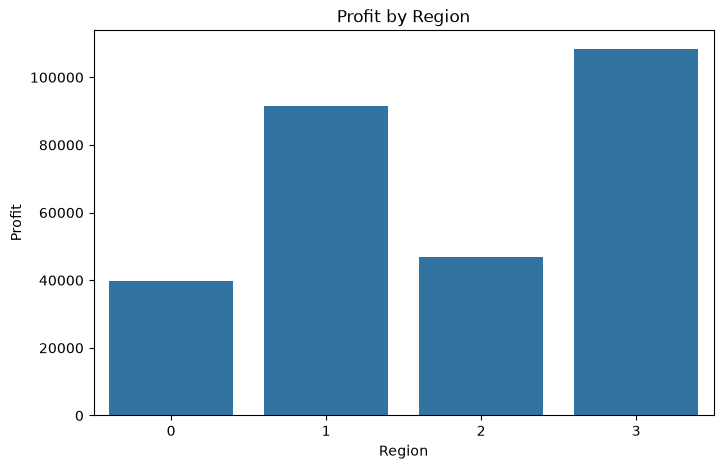

In [22]:
profit_region = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_region.index,
    y=profit_region.values
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

**Sales Distribution**
  - This histogram shows how sales values are distributed.

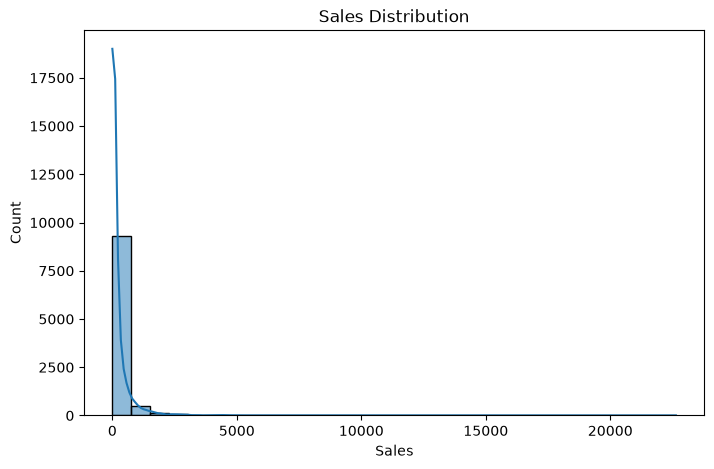

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")

plt.show()

**Profit Distribution**
  - This box plot helps identify outliers in profit.

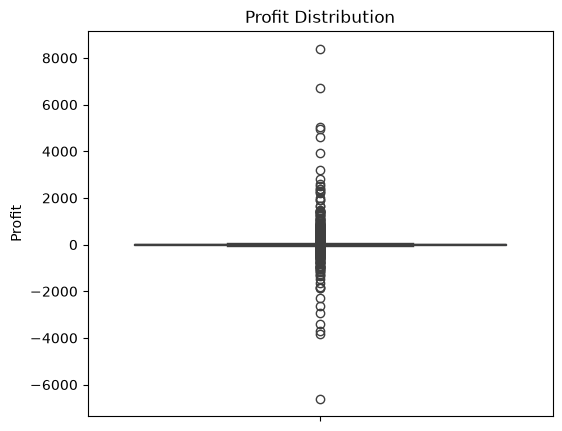

In [24]:
plt.figure(figsize=(6,5))

sns.boxplot(
    y=df["Profit"]
)

plt.title("Profit Distribution")

plt.show()

In [25]:
!pip install  feature_engine

Defaulting to user installation because normal site-packages is not writeable


In [26]:
from feature_engine.outliers import Winsorizer
win=Winsorizer(capping_method='iqr',tail='both',fold=1.5,variables=['Profit'])
df_win=win.fit_transform(df[['Profit']])
df_win

,Profit
0,41.913600
1,70.816875
2,6.871400
3,-39.724125
4,2.516400
...,...
9989,4.102800
9990,15.633200
9991,19.393200
9992,13.320000


In [27]:
print(win.left_tail_caps_,win.right_tail_caps_)

{'Profit': -39.724125} {'Profit': 70.816875}


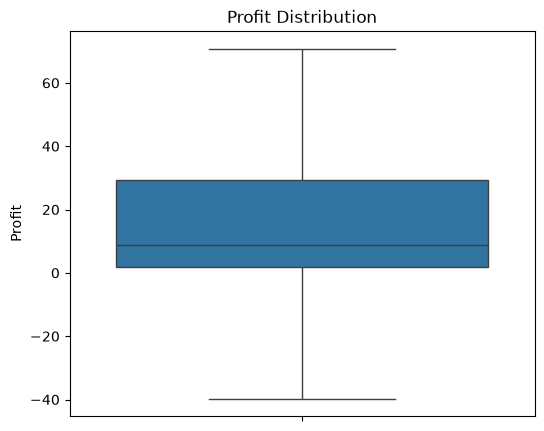

In [28]:
#After Removing the Outliers

plt.figure(figsize=(6,5))

sns.boxplot(
    y=df_win["Profit"]
)

plt.title("Profit Distribution")

plt.show()

**Correlation Heatmap**
  - This heatmap shows the correlation between numerical features.

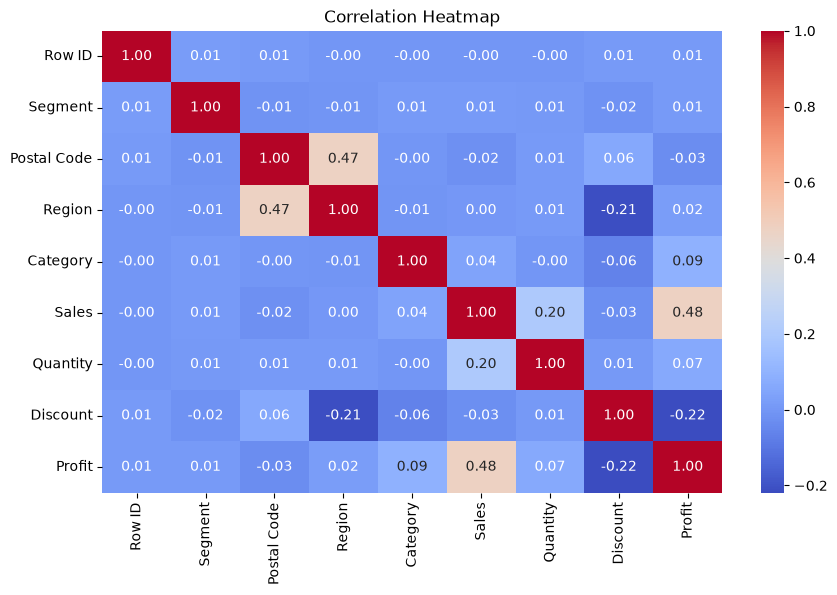

In [29]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# 5.Feature Engineering

- Feature Engineering is the process of creating, selecting, and transforming features that help improve the performance of the machine learning model. Instead of using raw data directly, new meaningful features are extracted to better represent the underlying patterns in the data.

- For the AI-Based Sales Forecasting Dashboard, feature engineering includes extracting date-related information, encoding categorical variables, and selecting the most important features for predicting future sales.

**Objectives**
  - Extract useful information from the Order Date.
  - Convert categorical variables into numerical values.
  - Select relevant input features.
  - Define the target variable.
  - Prepare the dataset for model training.

**Create Date Features**

  - Extract Year, Month, and Day from the Order Date column.

In [30]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day

In [31]:
# Check the new Columns

df[["Order Date", "Year", "Month", "Day"]].head()

,Order Date,Year,Month,Day
0,2016-11-08,2016,11,8
1,2016-11-08,2016,11,8
2,2016-06-12,2016,6,12
3,2015-10-11,2015,10,11
4,2015-10-11,2015,10,11


**Select Input Features**

  - Choose the columns that will be used to predict sales.

In [32]:
X = df[[
    "Year",
    "Month",
    "Day",
    "Region",
    "Category",
    "Quantity",
    "Profit"
]]

**Select Target Variable**

  - The value that the model will predict is Sales.

In [33]:
y = df["Sales"]

- Display the Final Features

In [34]:
print(X)

      Year  Month  Day  Region  Category  Quantity    Profit
0     2016     11    8       2         0         2   41.9136
1     2016     11    8       2         0         3  219.5820
2     2016      6   12       3         1         2    6.8714
3     2015     10   11       2         0         5 -383.0310
4     2015     10   11       2         1         2    2.5164
...    ...    ...  ...     ...       ...       ...       ...
9989  2014      1   21       2         0         3    4.1028
9990  2017      2   26       3         0         2   15.6332
9991  2017      2   26       3         2         2   19.3932
9992  2017      2   26       3         1         4   13.3200
9993  2017      5    4       3         1         2   72.9480

[9994 rows x 7 columns]


- Display the Target Variable

In [35]:
print(y)

0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9989     25.2480
9990     91.9600
9991    258.5760
9992     29.6000
9993    243.1600
Name: Sales, Length: 9994, dtype: float64


# 6.Model Training

- Model Training is the process of teaching a machine learning algorithm to learn the relationship between the input features and the target variable. During this phase, the dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used later to evaluate its performance.

- For the AI-Based Sales Forecasting Dashboard, the Random Forest Regressor is used because it is a robust algorithm that can capture complex relationships in the data and generally provides good prediction accuracy for regression problems.

**Objectives**
  - Split the dataset into training and testing sets.
  - Train a machine learning model using the training data.
  - Learn the relationship between input features and sales.
  - Prepare the trained model for evaluation and future predictions.


# 7.Model Evaluation


### Understanding the Evaluation Metrics
1. R² Score (Coefficient of Determination)
- Measures how well the model explains the variation in the target variable.
- Value ranges from 0 to 1.
- Higher is better.

**Examples:**

  - R² = 0.95 → The model explains 95% of the variation in sales.
  - R² = 0.60 → The model explains only 60% of the variation.
2. Mean Absolute Error (MAE)
- Measures the average absolute difference between actual and predicted sales.
- Expressed in the same units as the target variable.
Lower is better.

**Examples:**

  - MAE = 20 → Predictions are off by about 20 sales units on average.
  - MAE = 100 → Predictions are off by about 100 sales units on average.
3. Root Mean Squared Error (RMSE)
- Measures prediction error while giving more weight to larger errors.
- Lower is better.

**Examples:**

  - RMSE = 35 → Large prediction errors are relatively small.
  - RMSE = 150 → The model makes larger prediction errors.

**Split the Dataset**

  - Divide the dataset into 80% training data and 20% testing data.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [37]:
# Check the dataset sizes:

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (7995, 7)
Testing Features : (1999, 7)
Training Target  : (7995,)
Testing Target   : (1999,)


#### Model 1: Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [39]:
# Evaluation of Linear Regression

lr_r2 = r2_score(y_test, lr_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

print("Linear Regression")
print("R2 Score :", lr_r2)
print("MAE      :", lr_mae)
print("RMSE     :", lr_rmse)

Linear Regression
R2 Score : -0.1561895866761427
MAE      : 248.14428787037545
RMSE     : 826.4140735094616


#### Model 2: Decision Tree Regressor

In [40]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [41]:
# Evaluation of Decision Tree

dt_r2 = r2_score(y_test, dt_pred)

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)

print("Decision Tree")
print("R2 Score :", dt_r2)
print("MAE      :", dt_mae)
print("RMSE     :", dt_rmse)

Decision Tree
R2 Score : 0.46924458610201825
MAE      : 150.38725832916458
RMSE     : 559.9256902877728


#### Model 3: Random Forest Regressor

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [43]:
# Evaluation of Random Forest

rf_r2 = r2_score(y_test, rf_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("Random Forest")
print("R2 Score :", rf_r2)
print("MAE      :", rf_mae)
print("RMSE     :", rf_rmse)

Random Forest
R2 Score : 0.5337690952667844
MAE      : 123.67988023161581
RMSE     : 524.7877714849591


  - **Compare All Models**

In [44]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ]

})

print(results)

               Model  R2 Score         MAE        RMSE
0  Linear Regression -0.156190  248.144288  826.414074
1      Decision Tree  0.469245  150.387258  559.925690
2      Random Forest  0.533769  123.679880  524.787771


**Sort by best model**

In [45]:
results = results.sort_values(
    by="R2 Score",
    ascending=False
)

print(results)

               Model  R2 Score         MAE        RMSE
2      Random Forest  0.533769  123.679880  524.787771
1      Decision Tree  0.469245  150.387258  559.925690
0  Linear Regression -0.156190  248.144288  826.414074


**Select  the Best Model**

In [46]:
best_model = results.iloc[0]

print("Best Model")

print(best_model)

Best Model
Model       Random Forest
R2 Score         0.533769
MAE             123.67988
RMSE           524.787771
Name: 2, dtype: object


# 8.Save The Model

 In this project, the Random Forest Regressor is selected as the final model because it achieved the best performance during evaluation. The model is saved using the joblib library in a .pkl (pickle) file.

**Objectives**
  - Save the best-performing machine learning model.
  - Avoid retraining the model every time.
  - Enable quick loading for future predictions.
  - Use the saved model in the Streamlit dashboard.

**Import Joblib**

In [47]:
import joblib

**Save the Best Model**

Assuming Random Forest is your best model:

In [48]:
joblib.dump(rf_model, "sales_forecasting_model.pkl")

print("Model saved successfully!")

Model saved successfully!


**Save the Label Encoders**

*Since you encoded Region and Category, save the encoders as well. Otherwise, the loaded model won't know how to convert text inputs into numbers.*

In [49]:
joblib.dump(le_region, "region_encoder.pkl")
joblib.dump(le_category, "category_encoder.pkl")

print("Encoders saved successfully!")

Encoders saved successfully!


# 9.Load the Model

In this project, the trained Random Forest Regressor and the saved Label Encoders are loaded using the joblib library. These loaded objects are then used in the Streamlit application to predict sales based on user inputs.

**Objectives**
- Load the trained machine learning model.
- Load the saved label encoders.
- Use the loaded model for sales prediction.
- Avoid retraining the model every time the application starts.

**Load the Saved Model**

In [50]:
# Load the trained model

model = joblib.load("sales_forecasting_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


**Load the Label Encoders**

In [51]:
# Load Region Encoder
le_region = joblib.load("region_encoder.pkl")

# Load Category Encoder
le_category = joblib.load("category_encoder.pkl")

print("Encoders loaded successfully!")

Encoders loaded successfully!


In [52]:
## Verify the Model

print(model)

RandomForestRegressor(random_state=42)


In [53]:
## Verify the Encoders

print(le_region.classes_)

print(le_category.classes_)

['Central' 'East' 'South' 'West']
['Furniture' 'Office Supplies' 'Technology']


**Make a Prediction Using the Loaded Model**

Create a sample input.

In [58]:
sample_data = [[
    2023,    # Year
    5,       # Month
    15,      # Day
    le_region.transform(["West"])[0],
    le_category.transform(["Technology"])[0],
    3,       # Quantity
    250      # Profit
]]

In [59]:
# Predict sales.

prediction = model.predict(sample_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 1124.344519999999


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# 10.Sales Prediction

- In this project, the saved Random Forest Regressor model is used to generate sales predictions. Before prediction, the categorical inputs (Region and Category) are converted into numerical values using the saved Label Encoders. The predicted sales value is then displayed to the user through the Streamlit dashboard.

**Objectives**
  - Accept user input for sales-related features.
  - Convert categorical values using the saved label encoders.
  - Use the loaded machine learning model for prediction.
  - Display the predicted sales amount.

**Load the Saved Model and Encoders**

In [60]:
model = joblib.load("sales_forecasting_model.pkl")

le_region = joblib.load("region_encoder.pkl")

le_category = joblib.load("category_encoder.pkl")

**Get User Input**

In [62]:
year = int(input("Enter Year: "))
month = int(input("Enter Month: "))
day = int(input("Enter Day: "))

region = input("Enter Region: ")

category = input("Enter Category: ")

quantity = int(input("Enter Quantity: "))

profit = float(input("Enter Profit: "))

**Encode Categorical Features**

In [63]:
region = le_region.transform([region])[0]

category = le_category.transform([category])[0]

**Prepare the Input Data**

In [64]:
input_data = pd.DataFrame({

    "Year":[year],
    "Month":[month],
    "Day":[day],
    "Region":[region],
    "Category":[category],
    "Quantity":[quantity],
    "Profit":[profit]

})

**Predict Sales**

In [65]:
prediction = model.predict(input_data)

**Display Prediction**

In [66]:
print("Predicted Sales : $", round(prediction[0],2))

Predicted Sales : $ 1150.78
